# Chignolin Folding Dynamics iMSM Tutorial

This notebook demonstrates the general coordinate-based **interaction Markov State Model (iMSM)** pipeline applied to conformational folding dynamics of the 10-residue mini-protein Chignolin.

### Physical Representation & Method Overview
iMSMs coarse-grain over microscopic contact configurations that need not share identical Cartesian geometries, provided they preserve the same statistical interaction pattern around a selected focal entity:
1. **Partitioning the System**: The peptide is partitioned into interacting components $\mathcal{C} = \{c_1, \ldots, c_N\}$ (all C$\alpha$ atoms) and a chosen focal entity $f$ (a selected C$\alpha$ residue, e.g., $C_1, \ldots, C_{10}$) whose local interaction environment is tracked.
2. **Interaction Trajectory $I(t)$**: MD trajectories are converted into an interaction trajectory $I(t)$ recording intramolecular contacts between $f$ and other residues within a contact cutoff distance (`max_surface_dist`).
3. **Windowed Interaction Histograms $H$**: $I(t)$ is partitioned into consecutive time windows of duration $\tau$ (`window_size`). The interaction distribution in each window is summarized into an interaction histogram $H$, normalized by a fixed reference `interaction_capacity`. This captures both the identity of interacting residues and the focal residue's engagement level, distinguishing folded, intermediate, and unfolded contact topologies.
4. **Unsupervised Clustering**: Histograms are clustered into a reduced set of recurring conformational/interaction states $\mathcal{S} = \{s_1, \ldots, s_k\}$.
5. **Lagged Transition Matrix $T_{ij}$**: Transitions between states at lag time $\tau$ are recorded to construct the transition-probability matrix:
   $$T_{ij} = P(s(t+\tau) = s_j \mid s(t) = s_i)$$
   yielding a compact kinetic model of folding/unfolding pathways and stationary populations.

**Input Data Reference:**
Wang, T., He, X., Li, M. et al. *AIMD-Chig: Exploring the conformational space of a 166-atom protein Chignolin with ab initio molecular dynamics*. Sci Data 10, 549 (2023). https://doi.org/10.1038/s41597-023-02465-9


## 0. Set paths

In [ ]:
# ~~~~~~~~~~~~~~~~~~~~~~~ #
# Set your own paths here #
# ~~~~~~~~~~~~~~~~~~~~~~~ #
CHINGOLIN_DATA_PATH = "data/chignolin/Coordinates/"
IMSM_CHECKPOINT_PATH = "data/chignolin/imsm"

## 1. Import Required Libraries
The following cell imports necessary libraries for numerical operations, file I/O, and iMSM functionality.

In [ ]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
from ase.io import read
from iMSM.data_classes.input_data_classes import iMSMInput, iMSMInputSingleSim
from iMSM.data_classes.config_data_class import iMSMConfig
from iMSM.main import run

## 2. Load Chignolin Trajectories and Prepare Input

Loads Chignolin coordinates from `.xyz` simulation files using the Atomic Simulation Environment (ASE), extracts C $\alpha$ positions, and prepares an `iMSMInput` object defining the focal entity $f$ and interacting components $\mathcal{C}$.


In [ ]:
# Load the chignolin coordinates
trajectories = []

alpha_carbon_indexes = [5, 26, 46, 60, 71, 86, 100, 107, 121, 152]
alpha_carbon_tags = [f'C{i}' for i in range(10)]
alpha_carbon_tags = np.array(alpha_carbon_tags)

for folder_index in range(10):
    if folder_index % 5 == 0:
        print(f"Processing folder {folder_index}...")
    for sim_index in range(100):
        try:
            frames = read(f'{CHINGOLIN_DATA_PATH}/0/Coordinates_{sim_index}.xyz', index=':')
        except:
            continue
        coords = np.array([f.get_positions()[alpha_carbon_indexes] for f in frames])
        final_coords = coords.transpose(1, 2, 0) # Shape: (N_C_atoms, 3, N_timepoints)
        single_sim_input = iMSMInputSingleSim(trajectory=final_coords)
        trajectories.append(single_sim_input)
    
# Create the iMSMInput object
imsminput = iMSMInput(trajectories=trajectories, components=alpha_carbon_tags, focal_component="C0")

# pickle it 
with open(f"{IMSM_CHECKPOINT_PATH}/input.pickle", "wb") as f:
    pickle.dump(imsminput, f)

Processing folder 0...
Processing folder 5...


## 3. Configure and Run iMSM
Sets up the iMSM physical representation for each C $\alpha$ residue as the focal entity: contact cutoff (`max_surface_dist`), reference `interaction_capacity`, window duration $\tau$ (`window_size`), and clustering resolution (`n_clusters`).


In [ ]:
# Create configuration for iMSM
for focal_component in focal_components:
    print(f"Running iMSM for focal component: {focal_component}")
    config = iMSMConfig(checkpoints_path=f"{IMSM_CHECKPOINT_PATH}/{focal_component}/")
    
    # Contact definition: maximum distance for two components to be considered in contact (Angstroms)
    config.max_surface_dist = 10.0
    
    # Reference interaction capacity: maximum contact partners to record per frame and normalize histograms H
    config.interaction_capacity = 5
    
    # Window duration tau: number of consecutive frames for time-averaged interaction histograms
    config.window_size = 10
    
    # Number of recurring interaction states (mesostates) for clustering
    config.n_clusters = 100
    
    # Transition matrix pseudo-count prior
    config.tm_prior = 0.01

    run(imsm_input_dict[focal_component], config)


## 4. Visualize Recurring Interaction States and Transition Matrix $T_{ij}$
Visualizes the recurring interaction state compositions (histograms $H$) and the lagged transition-probability matrix $T_{ij}$ for a selected focal entity, revealing the kinetic pathways between contact topologies.


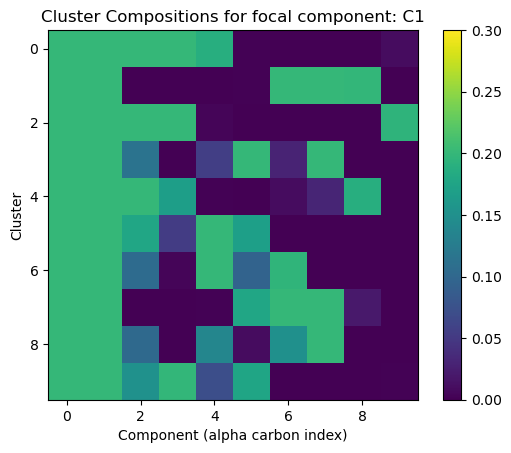

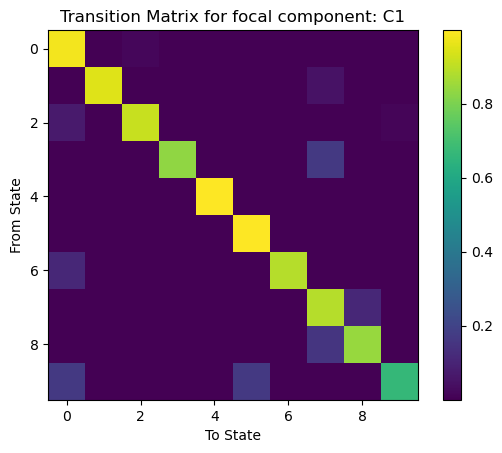

In [ ]:
focal_component = "C1"
    
# visualize cluster compositions
cluster_compositons = np.zeros((10,10))
with open(f"{IMSM_CHECKPOINT_PATH}/{focal_component}/3_clustering.pickle", "rb") as f:
    imsm_cluster = pickle.load(f)
for i in range(imsm_cluster.n_clusters):
    cluster_composition = imsm_cluster.clustering.cluster_centers_[i]
    cluster_compositons[i] = cluster_composition
plt.imshow(cluster_compositons, cmap='viridis')
plt.colorbar()
plt.title("Cluster Compositions for focal component: " + focal_component)
plt.xlabel("Component (alpha carbon index)")
plt.ylabel("Cluster")
plt.clim(0, 0.3)
plt.show()

# visualize the msm transition matrix
with open(f"{IMSM_CHECKPOINT_PATH}/{focal_component}/4_msm.pickle", "rb") as f:
    imsm_msm = pickle.load(f)
msm_matrix = imsm_msm.transition_matrix
plt.imshow(msm_matrix, cmap='viridis')
plt.colorbar()
plt.title("Transition Matrix for focal component: " + focal_component)
plt.xlabel("To State")
plt.ylabel("From State")
plt.show()